<a href="https://colab.research.google.com/github/BenGreenleaf/Helios/blob/main/injector_orifice_sizing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hydrogen Choked Orifice Sizing
## Injector Head Diameter Justification — Helios Project

Calculates choked mass flow rate through candidate orifice diameters (4, 5, 6 mm)  
at 7 bar upstream pressure, and plots mass flow vs diameter across the full range.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

## 1. Gas properties and stagnation conditions

In [ ]:
# Hydrogen thermodynamic properties
gamma = 1.405          # ratio of specific heats (diatomic H2)
M     = 2.016e-3       # molar mass [kg/mol]
R_u   = 8.314          # universal gas constant [J/mol/K]
R     = R_u / M        # specific gas constant [J/kg/K]

# Stagnation (feed) conditions
P0    = 7.0e5          # upstream stagnation pressure [Pa]
T0    = 290.0          # upstream stagnation temperature [K]

# Orifice discharge coefficient (sharp-edged)
Cd    = 0.55

print(f"Specific gas constant R = {R:.1f} J/kg/K")
print(f"P0 = {P0/1e5:.1f} bar,  T0 = {T0:.0f} K,  Cd = {Cd}")

Specific gas constant R = 4124.0 J/kg/K
P0 = 7.0 bar,  T0 = 290 K,  Cd = 0.55


## 2. Critical (choke) ratios at Ma = 1

From isentropic relations evaluated at Ma = 1:

$$\frac{P^*}{P_0} = \left(\frac{2}{\gamma+1}\right)^{\gamma/(\gamma-1)} \qquad \frac{T^*}{T_0} = \frac{2}{\gamma+1}$$

In [ ]:
P_ratio = (2 / (gamma + 1)) ** (gamma / (gamma - 1))
T_ratio = 2 / (gamma + 1)
rho_ratio = (2 / (gamma + 1)) ** (1 / (gamma - 1))

print(f"Critical pressure ratio  P*/P0  = {P_ratio:.4f}")
print(f"Critical temperature ratio T*/T0 = {T_ratio:.4f}")
print(f"Critical density ratio  rho*/rho0 = {rho_ratio:.4f}")
print(f"\nMax allowable back-pressure for choke: {P_ratio * P0/1e5:.3f} bar")

Critical pressure ratio  P*/P0  = 0.5274
Critical temperature ratio T*/T0 = 0.8316
Critical density ratio  rho*/rho0 = 0.6342

Max allowable back-pressure for choke: 3.692 bar


## 3. Discharge function Γ

Collects the γ-dependent terms from the choked mass flow equation:

$$\Gamma = \sqrt{\gamma \left(\frac{2}{\gamma+1}\right)^{(\gamma+1)/(\gamma-1)}}$$

In [ ]:
GAMMA = np.sqrt(gamma * (2 / (gamma + 1)) ** ((gamma + 1) / (gamma - 1)))
print(f"Discharge function Γ = {GAMMA:.4f}")

Discharge function Γ = 0.6856


## 4. Choked mass flow function

$$\dot{m} = C_d \cdot A^* \cdot \frac{P_0 \, \Gamma}{\sqrt{R T_0}}$$

where $A^* = \pi d^{*2}/4$.

In [ ]:
def choked_mdot(d_mm, Cd=Cd, P0=P0, T0=T0):
    """Return choked mass flow [g/s] for orifice diameter d_mm [mm]."""
    A = np.pi * (d_mm / 2e3) ** 2          # throat area [m^2]
    mdot = Cd * A * P0 * GAMMA / np.sqrt(R * T0)
    return mdot * 1e3                       # convert kg/s -> g/s

# Candidate diameters
candidates = [4, 5, 6]
print("Candidate orifice results at 7 bar, Cd = 0.61:")
print(f"{'Diameter (mm)':<16} {'Mass flow (g/s)':<18} {'In 3-6 g/s range?'}")
print("-" * 50)
for d in candidates:
    m = choked_mdot(d)
    in_range = "YES" if 3 <= m <= 6 else "outside range"
    print(f"{d:<16} {m:<18.2f} {in_range}")

Candidate orifice results at 7 bar, Cd = 0.61:
Diameter (mm)    Mass flow (g/s)    In 3-6 g/s range?
--------------------------------------------------
4                3.03               YES
5                4.74               YES
6                6.82               outside range


## 5. Plot — mass flow vs orifice diameter

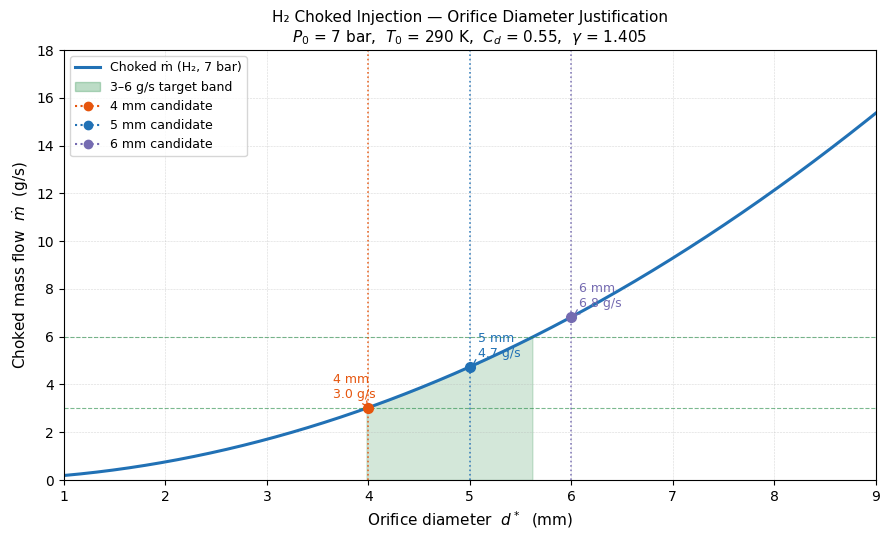

Figure saved as h2_orifice_sizing.png


In [ ]:
# Diameter sweep
d_arr  = np.linspace(1, 9, 500)
m_arr  = choked_mdot(d_arr)

# Target band mask
band_mask = (m_arr >= 3) & (m_arr <= 6)

fig, ax = plt.subplots(figsize=(9, 5.5))

# Main curve
ax.plot(d_arr, m_arr, color='#2171b5', linewidth=2.2, label='Choked mass flow (H₂, 7 bar)')

# Target band shading
ax.fill_between(d_arr, m_arr, where=band_mask,
                color='#238b45', alpha=0.20, label='3–6 g/s target band')
ax.axhline(3, color='#238b45', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axhline(6, color='#238b45', linewidth=0.8, linestyle='--', alpha=0.6)

# Candidate diameter lines and annotations
colours = {'4': '#e6550d', '5': '#2171b5', '6': '#756bb1'}
offsets = {'4': (-0.35, 0.4), '5': (0.08, 0.4), '6': (0.08, 0.4)}
for d in candidates:
    m = choked_mdot(d)
    col = colours[str(d)]
    ax.axvline(d, color=col, linewidth=1.2, linestyle=':', alpha=0.85)
    ax.plot(d, m, 'o', color=col, markersize=7, zorder=5)
    dx, dy = offsets[str(d)]
    ax.annotate(f'{d} mm\n{m:.1f} g/s',
                xy=(d, m), xytext=(d + dx, m + dy),
                fontsize=9, color=col,
                arrowprops=dict(arrowstyle='->', color=col, lw=0.9))

# Labels and formatting
ax.set_xlabel('Orifice diameter  $d^*$  (mm)', fontsize=11)
ax.set_ylabel('Choked mass flow  $\\dot{m}$  (g/s)', fontsize=11)
ax.set_title('H₂ Choked Injection — Orifice Diameter Justification\n'
             f'$P_0$ = 7 bar,  $T_0$ = 290 K,  $C_d$ = {Cd},  $\\gamma$ = {gamma}',
             fontsize=11)
ax.set_xlim(1, 9)
ax.set_ylim(0, 18)
ax.set_xticks(range(1, 10))
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5)

# Legend
handles = [
    Line2D([0],[0], color='#2171b5', linewidth=2.2),
    mpatches.Patch(color='#238b45', alpha=0.3),
    Line2D([0],[0], color='#e6550d', linestyle=':', marker='o', markersize=6),
    Line2D([0],[0], color='#2171b5', linestyle=':', marker='o', markersize=6),
    Line2D([0],[0], color='#756bb1', linestyle=':', marker='o', markersize=6),
]
labels = ['Choked ṁ (H₂, 7 bar)', '3–6 g/s target band', '4 mm candidate', '5 mm candidate', '6 mm candidate']
ax.legend(handles, labels, fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('h2_orifice_sizing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as h2_orifice_sizing.png")

## 6. Sensitivity — effect of Cd and temperature

In [ ]:
# Show how mass flow at 5 mm varies with Cd and T0
d_nom = 5.0

print("Sensitivity at d* = 5 mm, P0 = 7 bar")
print("\n--- Discharge coefficient sweep (T0 = 290 K) ---")
print(f"{'Cd':<8} {'ṁ (g/s)'}")
for cd in [0.55, 0.58, 0.61, 0.65, 0.70, 0.80]:
    print(f"{cd:<8.2f} {choked_mdot(d_nom, Cd=cd):.2f}")

print("\n--- Temperature sweep (Cd = 0.61) ---")
print(f"{'T0 (K)':<10} {'ṁ (g/s)'}")
for t in [250, 270, 290, 310, 330]:
    print(f"{t:<10} {choked_mdot(d_nom, T0=t):.2f}")

Sensitivity at d* = 5 mm, P0 = 7 bar

--- Discharge coefficient sweep (T0 = 290 K) ---
Cd       ṁ (g/s)
0.55     4.74
0.58     5.00
0.61     5.26
0.65     5.60
0.70     6.03
0.80     6.89

--- Temperature sweep (Cd = 0.61) ---
T0 (K)     ṁ (g/s)
250        5.10
270        4.91
290        4.74
310        4.58
330        4.44
